In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import kpss

In [2]:
df=pd.read_csv("DATA/onion.csv")

df

,Date,price
0,2000-01-01 00:00:00,89.8
1,2000-02-01 00:00:00,77.4
2,2000-03-01 00:00:00,83.0
3,2000-04-01 00:00:00,81.6
4,2000-05-01 00:00:00,88.9
...,...,...
277,2023-02-01 00:00:00,159.5
278,2023-03-01 00:00:00,138.1
279,2023-04-01 00:00:00,128.2
280,2023-05-01 00:00:00,129.2


Missing values:
Date     0
price    0
dtype: int64

Duplicates:
0

Basic statistics of Price:
count    282.000000
mean     227.401064
std      129.259780
min       77.400000
25%      138.475000
50%      199.400000
75%      268.275000
max      845.600000
Name: price, dtype: float64


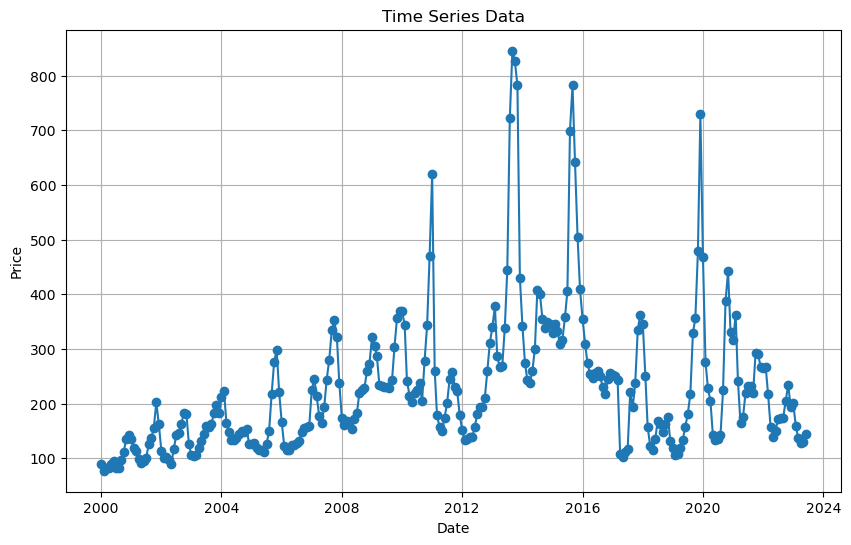

In [3]:
import pandas as pd


# Convert 'Date' column to datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicates:")
print(df.duplicated().sum())

# Check basic statistics of the 'Price' column
print("\nBasic statistics of Price:")
print(df['price'].describe())

# Plot the time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o')
plt.title('Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()


<Axes: >

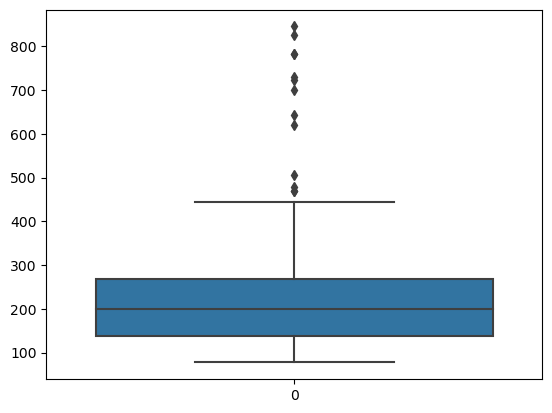

In [6]:
sn.boxplot(df['price'])

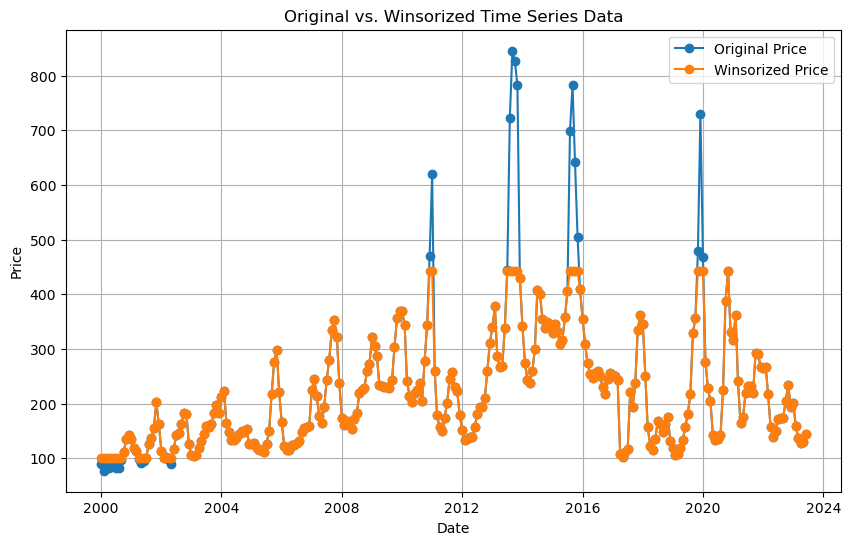

In [4]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values


# Winsorize the 'Price' column
#df['Price_winsorized'] = winsorize_outliers(df['price'])
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)


# Plot the original and winsorized time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o', label='Original Price')
plt.plot(df['Date'], df['price1'], marker='o', label='Winsorized Price')
plt.title('Original vs. Winsorized Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


<Axes: >

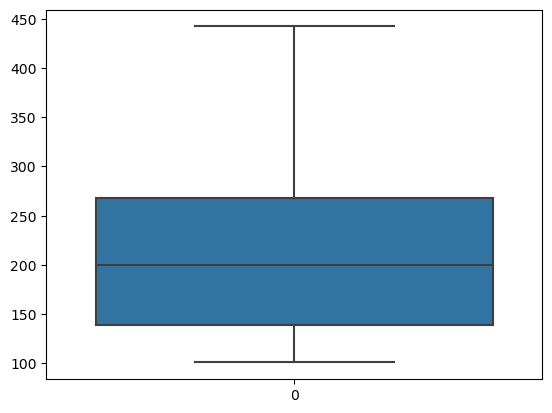

In [5]:
sn.boxplot(df['price1'])

In [7]:
t=kpss(df['price1'],'ct')
t

/var/folders/35/vcbg9sn9479dqrdl_3fgrrkh0000gn/T/ipykernel_28449/4116826920.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  t=kpss(df['price1'],'ct')


(0.3467564624197358,
 0.01,
 9,
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

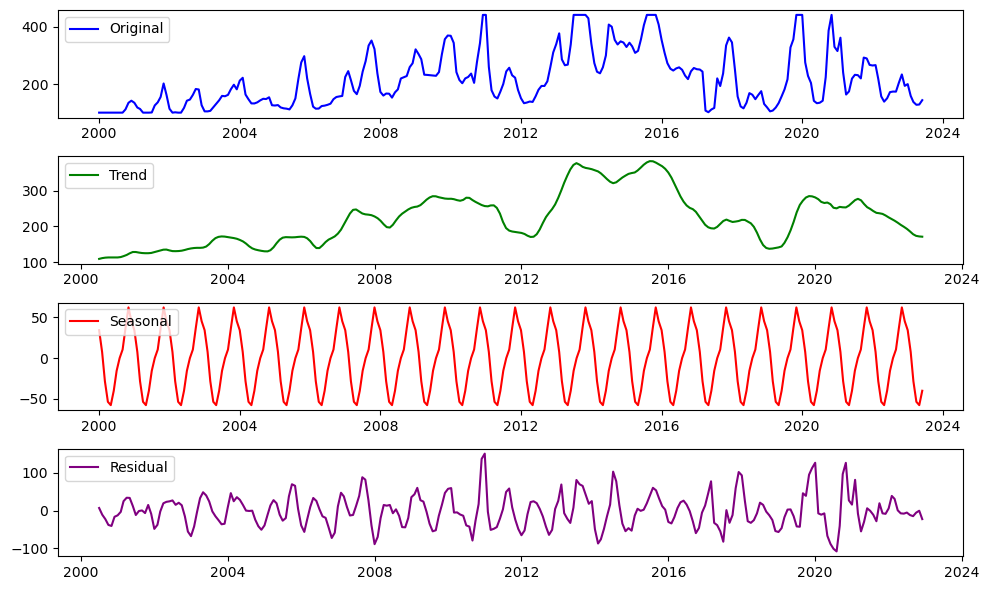

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming df is your DataFrame with a 'date' column and a 'value' column representing the time series
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['price1'], model='additive')

# Plot the original time series
plt.figure(figsize=(10, 6))
plt.subplot(411)
plt.plot(df['price1'], label='Original', color='blue')
plt.legend(loc='upper left')

# Plot the trend component
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='green')
plt.legend(loc='upper left')

# Plot the seasonal component
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='red')
plt.legend(loc='upper left')

# Plot the residual component
plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='purple')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [80]:
df=pd.read_csv("DATA/Backup/onion.csv")

Missing values:
Date     0
price    0
dtype: int64

Duplicates:
0

Basic statistics of Price:
count    288.000000
mean     229.182292
std      129.215875
min       77.400000
25%      139.525000
50%      201.800000
75%      273.375000
max      845.600000
Name: price, dtype: float64


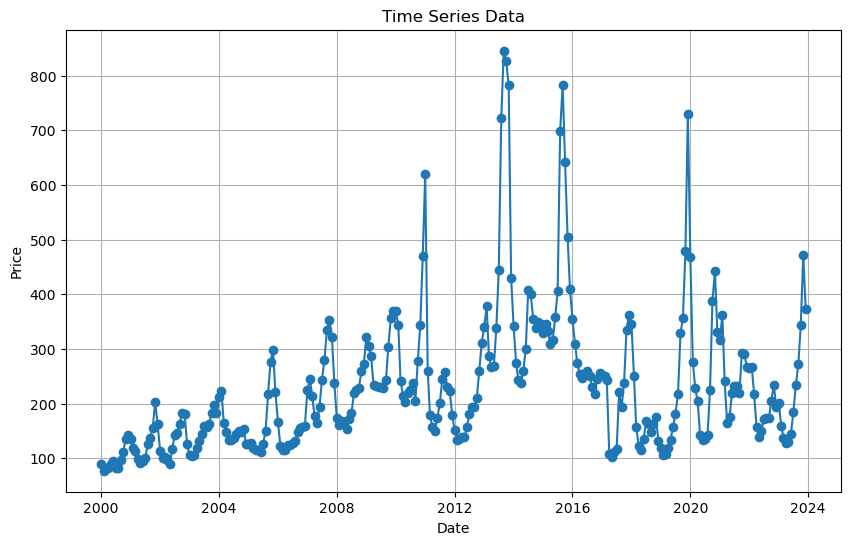

In [81]:
import pandas as pd


# Convert 'Date' column to datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicates:")
print(df.duplicated().sum())

# Check basic statistics of the 'Price' column
print("\nBasic statistics of Price:")
print(df['price'].describe())

# Plot the time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o')
plt.title('Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()


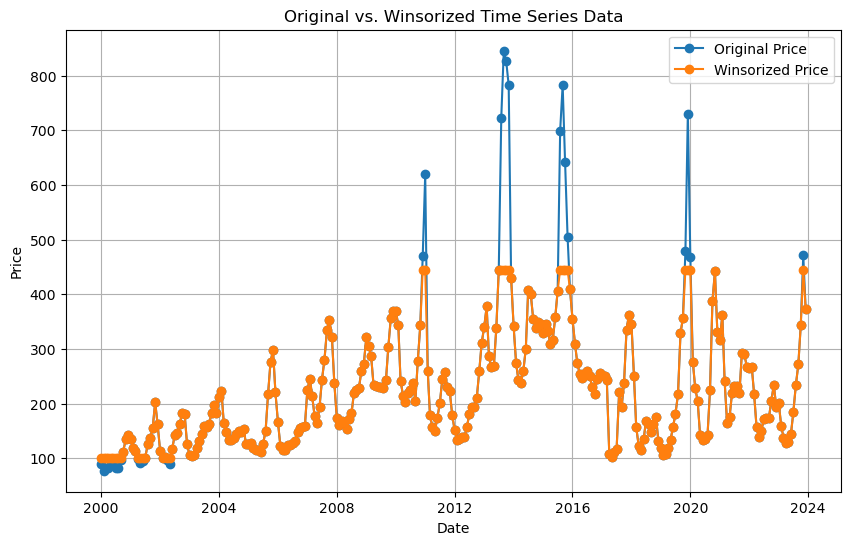

In [82]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values


# Winsorize the 'Price' column
#df['Price_winsorized'] = winsorize_outliers(df['price'])
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)


# Plot the original and winsorized time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o', label='Original Price')
plt.plot(df['Date'], df['price1'], marker='o', label='Winsorized Price')
plt.title('Original vs. Winsorized Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


In [83]:
df.pop('price')
df['price']=df.pop('price1')
df

,Date,price
0,2000-01-01,100.8
1,2000-02-01,100.8
2,2000-03-01,100.8
3,2000-04-01,100.8
4,2000-05-01,100.8
...,...,...
283,2023-08-01,233.9
284,2023-09-01,271.9
285,2023-10-01,343.4
286,2023-11-01,445.3


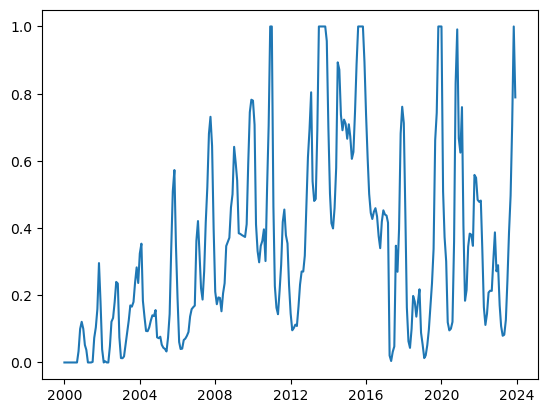

In [84]:

scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
import matplotlib.pyplot as plt
plt.plot(df['Date'],df['price'])

In [85]:
# Convert 'date' column to datetime if it's not already
# Shift the 'price' column to create new columns
scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
#import matplotlib.pyplot as plt
#plt.plot(df['Date'],df['price'])
shift=7
for i in range(shift):
    df['target-'+str(i+1)] = df['price'].shift(i+1)
#df['target-1'] = df['price'].shift(1)
#df['target-2'] = df['price'].shift(2)
#df['target-3'] = df['price'].shift(3)
#df['target-4'] = df['price'].shift(4)
#df['target-5'] = df['price'].shift(5)
#df['target-6'] = df['price'].shift(6)
#df['target-7'] = df['price'].shift(7)
#df['target-8'] = df['price'].shift(8)
#df['target-9'] = df['price'].shift(9)
#df['target-10'] = df['price'].shift(10)


In [86]:
d=df[shift:]
d

,Date,price,target-1,target-2,target-3,target-4,target-5,target-6,target-7
7,2000-08-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,2000-09-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,2000-10-01,0.033382,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10,2000-11-01,0.099855,0.033382,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11,2000-12-01,0.121045,0.099855,0.033382,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
283,2023-08-01,0.386357,0.242380,0.126560,0.082438,0.079536,0.108273,0.170392,0.289405
284,2023-09-01,0.496662,0.386357,0.242380,0.126560,0.082438,0.079536,0.108273,0.170392
285,2023-10-01,0.704209,0.496662,0.386357,0.242380,0.126560,0.082438,0.079536,0.108273
286,2023-11-01,1.000000,0.704209,0.496662,0.386357,0.242380,0.126560,0.082438,0.079536


In [87]:
def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()
    dates = df_as_np[:, 0]
    middle_matrix = df_as_np[:, 2:]
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))
    Y = df_as_np[:, 1:2]
    return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(d)

dates.shape, X.shape, y.shape

((281,), (281, 7, 1), (281, 1))

In [88]:
#y

In [89]:
#dates
#X
#y

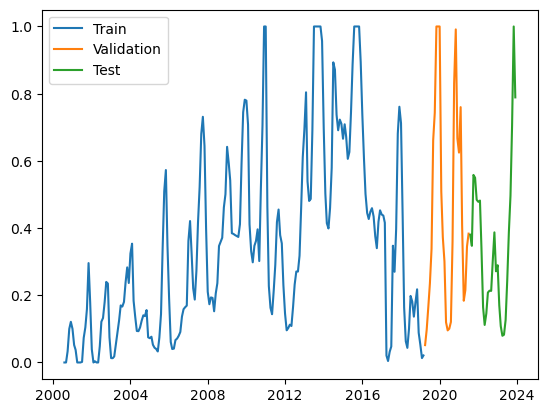

In [90]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]

dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

In [91]:
#X_train

In [92]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras import layers
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

#early_stopping = EarlyStopping(monitor='val_loss', patience=10, mode='min')

model = Sequential([layers.Input((shift, 1)),
                    #layers.GRU(64),
                    layers.LSTM(64),
                    #layers.LSTM(64, return_sequences=True),
                    #layers.LSTM(64),
                    #layers.Bidirectional(layers.LSTM(64)),
                    #layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
                    #layers.Flatten(),
                    layers.Dense(64, activation='relu'),
                    #layers.Dense(64, activation='relu'),
                    layers.Dense(1)
                   ])

model.compile(loss='mse', 
              optimizer=Adam(learning_rate=0.001),
              metrics=['mean_absolute_error'])

x=model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200)

Epoch 1/200
7/7 [==============================] - 1s 28ms/step - loss: 0.1250 - mean_absolute_error: 0.2641 - val_loss: 0.1573 - val_mean_absolute_error: 0.3009
Epoch 2/200
7/7 [==============================] - 0s 3ms/step - loss: 0.0517 - mean_absolute_error: 0.1769 - val_loss: 0.1384 - val_mean_absolute_error: 0.3234
Epoch 3/200
7/7 [==============================] - 0s 4ms/step - loss: 0.0491 - mean_absolute_error: 0.1841 - val_loss: 0.1376 - val_mean_absolute_error: 0.3214
Epoch 4/200
7/7 [==============================] - 0s 4ms/step - loss: 0.0441 - mean_absolute_error: 0.1693 - val_loss: 0.1382 - val_mean_absolute_error: 0.3059
Epoch 5/200
7/7 [==============================] - 0s 4ms/step - loss: 0.0436 - mean_absolute_error: 0.1624 - val_loss: 0.1353 - val_mean_absolute_error: 0.3082
Epoch 6/200
7/7 [==============================] - 0s 4ms/step - loss: 0.0416 - mean_absolute_error: 0.1623 - val_loss: 0.1341 - val_mean_absolute_error: 0.3150
Epoch 7/200
7/7 [================

7/7 [==============================] - 0s 3ms/step - loss: 0.0135 - mean_absolute_error: 0.0820 - val_loss: 0.0302 - val_mean_absolute_error: 0.1374
Epoch 102/200
7/7 [==============================] - 0s 3ms/step - loss: 0.0122 - mean_absolute_error: 0.0771 - val_loss: 0.0335 - val_mean_absolute_error: 0.1443
Epoch 103/200
7/7 [==============================] - 0s 3ms/step - loss: 0.0114 - mean_absolute_error: 0.0768 - val_loss: 0.0389 - val_mean_absolute_error: 0.1526
Epoch 104/200
7/7 [==============================] - 0s 3ms/step - loss: 0.0121 - mean_absolute_error: 0.0783 - val_loss: 0.0322 - val_mean_absolute_error: 0.1415
Epoch 105/200
7/7 [==============================] - 0s 3ms/step - loss: 0.0114 - mean_absolute_error: 0.0767 - val_loss: 0.0382 - val_mean_absolute_error: 0.1506
Epoch 106/200
7/7 [==============================] - 0s 3ms/step - loss: 0.0118 - mean_absolute_error: 0.0779 - val_loss: 0.0307 - val_mean_absolute_error: 0.1348
Epoch 107/200
7/7 [=================

In [93]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 64)                16896     
                                                                 
 dense_6 (Dense)             (None, 64)                4160      
                                                                 
 dense_7 (Dense)             (None, 1)                 65        
                                                                 
Total params: 21121 (82.50 KB)
Trainable params: 21121 (82.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


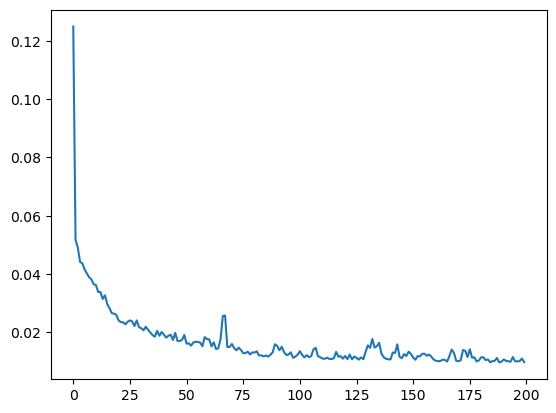

In [94]:
plt.plot(x.history['loss'])

In [95]:
# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training Loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing Loss: {test_loss}')


Training Loss: [0.009780551306903362, 0.07091256231069565]
Testing Loss: [0.011443903669714928, 0.07996901124715805]


7/7 [==============================] - 0s 1ms/step


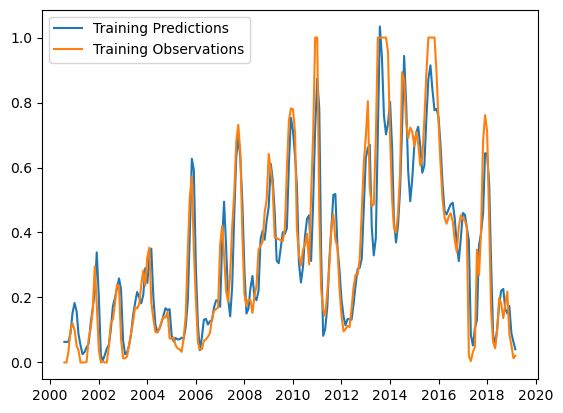

In [96]:
train_predictions = model.predict(X_train)

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)

#plt.plot(train_predictions)
#plt.plot(y_train)
plt.legend(['Training Predictions', 'Training Observations'])

1/1 [==============================] - 0s 142ms/step


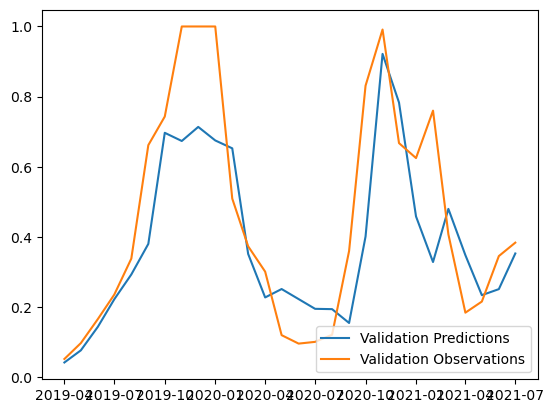

In [97]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

1/1 [==============================] - 0s 11ms/step


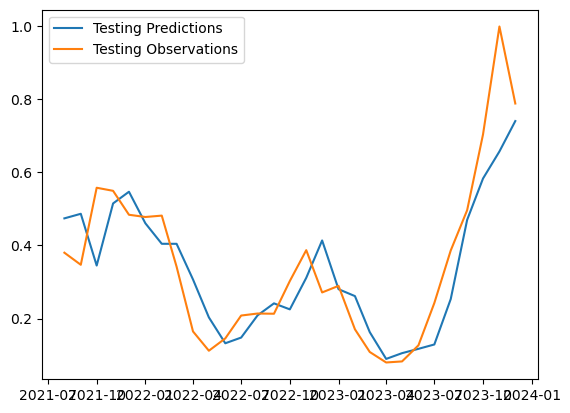

In [98]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Testing Predictions', 'Testing Observations'])

In [76]:
n = 50  # Change this value to forecast more or fewer values
forecast = []
last_data = X[-1]  # Last X data point
for i in range(n):
    next_y = model.predict(last_data.reshape(1, X.shape[1], X.shape[2]))  # Predict next y
    forecast.append(next_y)
    last_data = np.append(last_data[1:], next_y)  # Shift data by 1 and append next_y
forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))
print("Forecasted next", n, "y values:")
print(forecast)

1/1 [==============================] - 0s 8ms/step
Forecasted next 50 y values:
[[ 0.7348345 ]
 [ 0.6948703 ]
 [ 0.4256973 ]
 [ 0.17692205]
 [ 0.11987503]
 [ 0.55770534]
 [ 0.7163394 ]
 [ 0.36750948]
 [ 0.03106105]
 [ 0.03291207]
 [ 0.4425243 ]
 [ 0.7487912 ]
 [ 0.2824374 ]
 [-0.02315838]
 [-0.01152202]
 [ 0.3806405 ]
 [ 0.777413  ]
 [ 0.17154992]
 [-0.0348932 ]
 [-0.02417457]
 [ 0.36505187]
 [ 0.79914254]
 [ 0.10220627]
 [-0.04161338]
 [-0.02516774]
 [ 0.37069657]
 [ 0.81499743]
 [ 0.0540553 ]
 [-0.0451302 ]
 [-0.02236177]
 [ 0.38550895]
 [ 0.82742435]
 [ 0.01545784]
 [-0.04701703]
 [-0.01848408]
 [ 0.40524888]
 [ 0.8376757 ]
 [-0.0140968 ]
 [-0.04827417]
 [-0.01493244]
 [ 0.42604557]
 [ 0.8466949 ]
 [-0.03538602]
 [-0.04947541]
 [-0.01239669]
 [ 0.4452402 ]
 [ 0.8551969 ]
 [-0.04976529]
 [-0.05099485]
 [-0.01117783]]


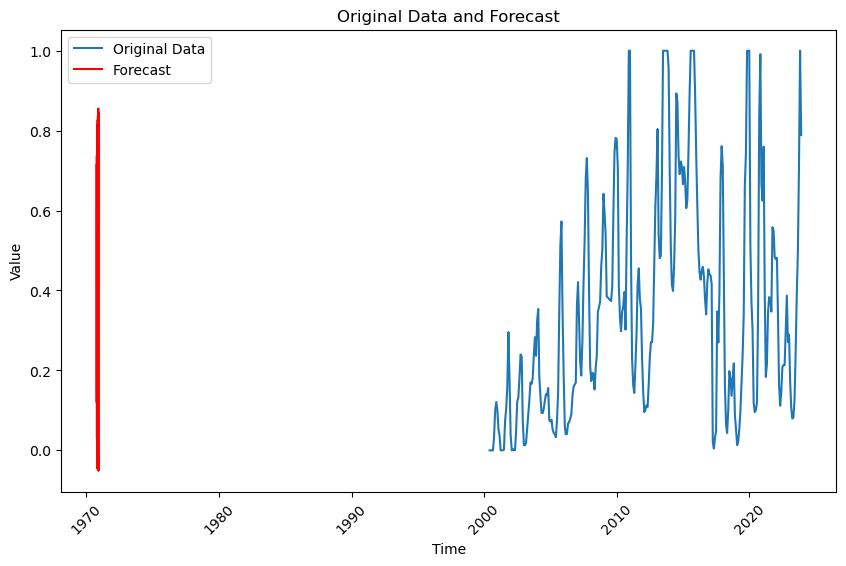

In [77]:
plt.figure(figsize=(10, 6))
plt.plot(dates, y, label='Original Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data and Forecast')
plt.xticks(rotation=45)
plt.legend()

# Plot forecast
forecast_dates = np.arange(len(y), len(y) + n)
plt.plot(forecast_dates, forecast, label='Forecast', color='red')
plt.legend()

plt.show()

In [99]:
# Inverse transform to get actual prices
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_pred_actual = scaler.inverse_transform(train_predictions.reshape(-1,1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))
y_val_pred_actual = scaler.inverse_transform(val_predictions.reshape(-1,1))
y_val_actual = scaler.inverse_transform(y_val.reshape(-1,1))


In [100]:
# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train_actual, y_train_pred_actual)
train_mse = mean_squared_error(y_train_actual, y_train_pred_actual)
val_mae = mean_absolute_error(y_val_actual, y_val_pred_actual)
test_mae = mean_absolute_error(y_test_actual, y_test_pred_actual)
test_mse = mean_squared_error(y_test_actual, y_test_pred_actual)
val_mse = mean_squared_error(y_val_actual, y_val_pred_actual)

print(f'Training MAE: {train_mae}')
print(f'Training MSE: {train_mse}')
print(f'Val MAE: {val_mae}')
print(f'Val MSE: {val_mse}')
print(f'Testing MAE: {test_mae}')
print(f'Testing MSE: {test_mse}')


train_r = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, y_train_pred_actual)
test_r = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_test_pred_actual)
val_r = np.sqrt(val_mse)
val_r2 = r2_score(y_val_actual, y_val_pred_actual)


print(train_r)
print(train_r2)
print(val_r)
print(val_r2)
print(test_r)
print(test_r2)

Training MAE: 0.07091256231069565
Training MSE: 0.009780549444258213
Val MAE: 0.13716647028923035
Val MSE: 0.03410765156149864
Testing MAE: 0.07996901124715805
Testing MSE: 0.011443904601037502
0.09889666
0.8731552836460942
0.18468256
0.6490641099313923
0.10697619
0.7630082612399169


In [140]:
# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train, train_predictions)
train_mse = mean_squared_error(y_train, train_predictions)
val_mae = mean_absolute_error(y_val, val_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
val_mse = mean_squared_error(y_val, val_predictions)

print(f'Training MAE: {train_mae}')
print(f'Training MSE: {train_mse}')
print(f'Testing MAE: {test_mae}')
print(f'Testing MSE: {test_mse}')
print(f'Testing MAE: {val_mae}')
print(f'Testing MSE: {val_mse}')

train_r = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, y_train_pred_actual)
test_r = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_test_pred_actual)
val_r = np.sqrt(val_mse)
val_r2 = r2_score(y_val_actual, y_val_pred_actual)


print(train_r)
print(val_r)
print(test_r)
print(train_r2)
print(val_r2)
print(test_r2)

Training MAE: 0.03931098058819771
Training MSE: 0.0032352623529732227
Testing MAE: 0.03548557311296463
Testing MSE: 0.0023003045935183764
Testing MAE: 0.056559350341558456
Testing MSE: 0.007438889238983393
0.056879368
0.086248994
0.047961492
0.9026494483238845
0.8178772464656185
0.821485557583796


In [136]:
model.save('onion_cnn')

INFO:tensorflow:Assets written to: onion_cnn/assets


INFO:tensorflow:Assets written to: onion_cnn/assets


In [139]:
import tensorflow as tf
m1=tf.keras.models.load_model('onion_gru')
m1.layers[0].input_shape

(None, 3, 1)

In [140]:
test_predictions = m1.predict(X_test).flatten()

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))

test_r2 = r2_score(y_test_actual, y_test_pred_actual)
print(test_r2)
#plt.plot(dates_test, test_predictions)
#plt.plot(dates_test, y_test)
#plt.legend(['Testing Predictions', 'Testing Observations'])

1/1 [==============================] - 0s 144ms/step
0.6569322096157718


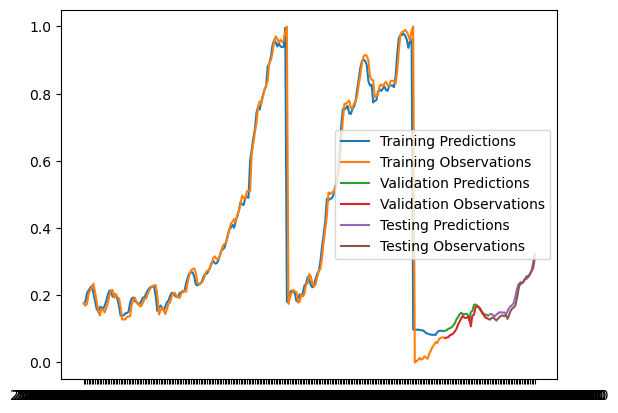

In [149]:
plt.plot(figsize=(100,100))
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations'])



In [150]:
from copy import deepcopy

recursive_predictions = []
recursive_dates = np.concatenate([dates_val, dates_test])

for target_date in recursive_dates:
    last_window = deepcopy(X_train[-1])
    next_prediction = model.predict(np.array([last_window])).flatten()
    recursive_predictions.append(next_prediction)
    last_window[-1] = next_prediction

1/1 [==============================] - 0s 8ms/step


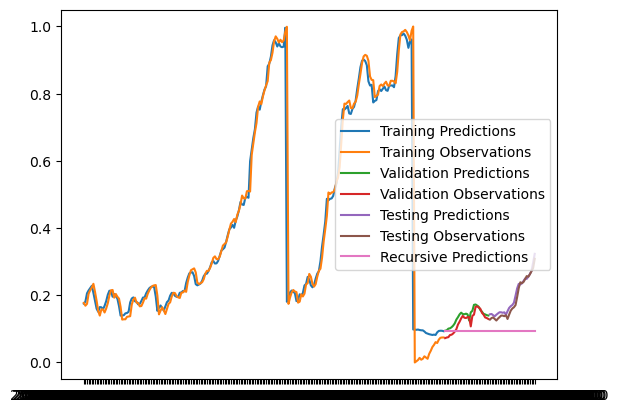

In [151]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.plot(recursive_dates, recursive_predictions)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations',
            'Recursive Predictions'])

In [72]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
# Sample DataFrame
#data = {'date': pd.date_range(start='2024-01-01', periods=100),
#        'price': np.random.rand(100)}
#df = pd.DataFrame(data)



In [63]:
# Normalize the price data
scaler = MinMaxScaler(feature_range=(0, 1))
d['price'] = scaler.fit_transform(d['Rice'].values.reshape(-1,1))

In [64]:
x=d.pop('Rice')
d

,date,price
0,2000-02-01,0.053404
1,2000-03-01,0.043292
2,2000-04-01,0.049974
3,2000-05-01,0.049490
4,2000-06-01,0.049135
...,...,...
235,2019-09-01,0.058386
236,2019-10-01,0.056683
237,2019-11-01,0.075554
238,2019-12-01,0.081035


In [65]:
# Function to create sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Hyperparameters
sequence_length = 10  # Adjust according to your choice
batch_size = 64
epochs = 100

# Create sequences
X, y = create_sequences(d['price'].values, sequence_length)

# Split the data into training and testing sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape input data for LSTM [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [73]:
# Define the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(sequence_length, 1)))
model.add(LSTM(units=50))
model.add(Dense(units=1))

In [74]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [75]:
# Train the model
model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)
# Define Early Stopping Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)


Epoch 1/100
3/3 [==============================] - 1s 6ms/step - loss: 0.0041
Epoch 2/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0026
Epoch 3/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0027
Epoch 4/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0023
Epoch 5/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0023
Epoch 6/100
3/3 [==============================] - 0s 5ms/step - loss: 0.0023
Epoch 7/100
3/3 [==============================] - 0s 5ms/step - loss: 0.0021
Epoch 8/100
3/3 [==============================] - 0s 5ms/step - loss: 0.0020
Epoch 9/100
3/3 [==============================] - 0s 5ms/step - loss: 0.0021
Epoch 10/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0020
Epoch 11/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0019
Epoch 12/100
3/3 [==============================] - 0s 6ms/step - loss: 0.0019
Epoch 13/100
3/3 [==============================] - 0s 6ms/st

In [76]:
# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training Loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing Loss: {test_loss}')


Training Loss: 0.0006569024408236146
Testing Loss: 0.04776032641530037


In [54]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Inverse transform to get actual prices
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_pred_actual = scaler.inverse_transform(y_train_pred)
y_test_pred_actual = scaler.inverse_transform(y_test_pred)

# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train_actual, y_train_pred_actual)
train_mse = mean_squared_error(y_train_actual, y_train_pred_actual)
test_mae = mean_absolute_error(y_test_actual, y_test_pred_actual)
test_mse = mean_squared_error(y_test_actual, y_test_pred_actual)
#
train_r = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, y_train_pred_actual)
test_r = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_test_pred_actual)

print(f'Training MAE: {train_mae}')
print(f'Training MSE: {train_mse}')
print(f'Testing MAE: {test_mae}')
print(f'Testing MSE: {test_mse}')
print(train_r)
print(test_r)
print(train_r2)
print(test_r2)

1/1 [==============================] - 0s 8ms/step
Training MAE: 15.197800636291504
Training MSE: 980.4922485351562
Testing MAE: 217.68800354003906
Testing MSE: 190393.921875
31.312813
436.34152
0.80162733858064
0.20735048207608497


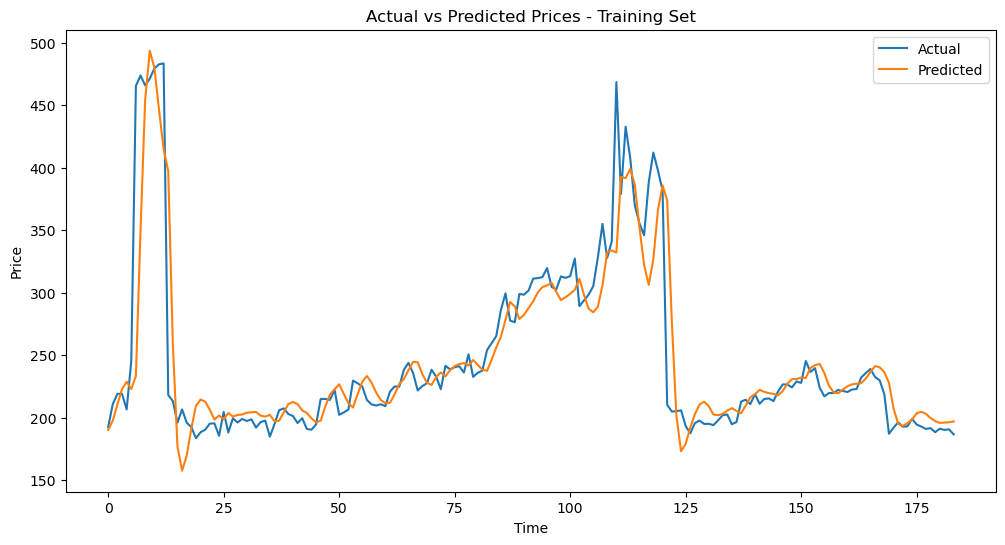

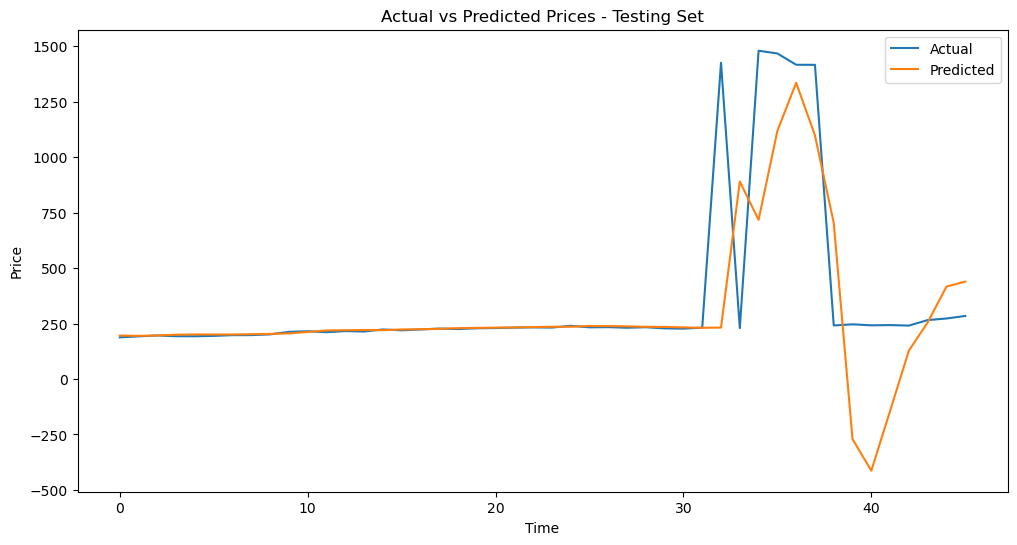

In [78]:
import matplotlib.pyplot as plt

# Plot actual vs predicted for training set
plt.figure(figsize=(12, 6))
plt.plot(y_train_actual, label='Actual')
plt.plot(y_train_pred_actual, label='Predicted')
plt.title('Actual vs Predicted Prices - Training Set')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Plot actual vs predicted for testing set
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual')
plt.plot(y_test_pred_actual, label='Predicted')
plt.title('Actual vs Predicted Prices - Testing Set')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [79]:
d

,date,price
0,2000-02-01,0.053404
1,2000-03-01,0.043292
2,2000-04-01,0.049974
3,2000-05-01,0.049490
4,2000-06-01,0.049135
...,...,...
235,2019-09-01,0.058386
236,2019-10-01,0.056683
237,2019-11-01,0.075554
238,2019-12-01,0.081035
